# Egression Power Characterization: 6 Detection Bands x 9 Measurement Maps

This notebook reproduces, **once per narrow detection band**, the full procedure from the guide notebook (originally run only on `test_egress_pwr.fits`, the 5-7 mHz cropped map):

1. Detect supergranule candidates (Gaussian smoothing → brightness threshold → morphological cleaning → watershed → circular masks) using **one narrow-band cropped file**.
2. Apply that fixed set of circular masks to **all 9 wide egression-power maps** (2-3 mHz through 10-11 mHz) to measure the mean egression power inside each supergranule, at every frequency.
3. Produce one mean-egression-power-vs-frequency curve per detection band.

The 6 cropped files below are used **only** to detect the circular masks (one independent detection per file, same as the original notebook did with `test_egress_pwr.fits`). All the measurement / plotting is done on the 9 (uncropped) maps in `files`, exactly like the guide notebook's cells 9-13.

```
cropped_files (masks only):
  egress_pwr_05.0-06.0mHz_z0000km_cropped.fits
  egress_pwr_06.0-07.0mHz_z0000km_cropped.fits
  egress_pwr_07.0-08.0mHz_z0000km_cropped.fits
  egress_pwr_08.0-09.0mHz_z0000km_cropped.fits
  egress_pwr_09.0-10.0mHz_z0000km_cropped.fits
  egress_pwr_10.0-11.0mHz_z0000km_cropped.fits

files (measurement, same as guide notebook):
  2.0-3.0, 3.0-4.0, 4.0-5.0, 5.0-6.0, 6.0-7.0, 7.0-8.0, 8.0-9.0, 9.0-10.0, 10.0-11.0 mHz
```

Result: **6 curves** of mean egression power vs frequency (9 points each, one per measurement map), one curve per detection band.

## 1. Imports

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from scipy.ndimage import (
    gaussian_filter,
    binary_closing,
    binary_fill_holes,
    distance_transform_edt
)

from skimage.morphology import remove_small_objects
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops


## 2. File Setup

In [30]:
base_path = "../data/2018_08_25"

# -----------------------------------------------------------
# Cropped files: used ONLY to detect the circular masks
# -----------------------------------------------------------
cropped_files = [
    "egress_pwr_05.0-06.0mHz_z0000km_cropped.fits",
    "egress_pwr_06.0-07.0mHz_z0000km_cropped.fits",
    "egress_pwr_07.0-08.0mHz_z0000km_cropped.fits",
    "egress_pwr_08.0-09.0mHz_z0000km_cropped.fits",
    "egress_pwr_09.0-10.0mHz_z0000km_cropped.fits",
    "egress_pwr_10.0-11.0mHz_z0000km_cropped.fits",
]

detection_band_labels = [
    "5.0-6.0 mHz",
    "6.0-7.0 mHz",
    "7.0-8.0 mHz",
    "8.0-9.0 mHz",
    "9.0-10.0 mHz",
    "10.0-11.0 mHz",
]

# -----------------------------------------------------------
# Wide (uncropped) maps: used for measurement, same as the
# guide notebook's cells 9-13
# -----------------------------------------------------------
files = {
    "2.0-3.0 mHz": "egress_pwr_02.0-03.0mHz_z0000km.fits",
    "3.0-4.0 mHz": "egress_pwr_03.0-04.0mHz_z0000km.fits",
    "4.0-5.0 mHz": "egress_pwr_04.0-05.0mHz_z0000km.fits",
    "5.0-6.0 mHz": "egress_pwr_05.0-06.0mHz_z0000km.fits",
    "6.0-7.0 mHz": "egress_pwr_06.0-07.0mHz_z0000km.fits",
    "7.0-8.0 mHz": "egress_pwr_07.0-08.0mHz_z0000km.fits",
    "8.0-9.0 mHz": "egress_pwr_08.0-09.0mHz_z0000km.fits",
    "9.0-10.0 mHz": "egress_pwr_09.0-10.0mHz_z0000km.fits",
    "10.0-11.0 mHz": "egress_pwr_10.0-11.0mHz_z0000km.fits",
}
measurement_frequencies = list(files.keys())

central_frequencies = np.array([2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5])

# Spatial sampling (same provisional value used in the guide notebook)
spatial_sample = 0.5 * 725 * 0.001  # Mm/pixel


In [31]:
# Load the 6 cropped maps (mask detection only)
detection_maps = []
for filename in cropped_files:
    path = os.path.join(base_path, filename)
    with fits.open(path) as hdul:
        d = hdul[0].data.astype(float).copy()
    detection_maps.append(d)
    print(f"[detection] {filename} -> shape {d.shape}")


[detection] egress_pwr_05.0-06.0mHz_z0000km_cropped.fits -> shape (1024, 1024)
[detection] egress_pwr_06.0-07.0mHz_z0000km_cropped.fits -> shape (1024, 1024)
[detection] egress_pwr_07.0-08.0mHz_z0000km_cropped.fits -> shape (1024, 1024)
[detection] egress_pwr_08.0-09.0mHz_z0000km_cropped.fits -> shape (1024, 1024)
[detection] egress_pwr_09.0-10.0mHz_z0000km_cropped.fits -> shape (1024, 1024)
[detection] egress_pwr_10.0-11.0mHz_z0000km_cropped.fits -> shape (1024, 1024)


In [32]:
# Load the 9 wide maps (measurement)
egression_maps = []
for freq_band, filename in files.items():
    path = os.path.join(base_path, filename)
    with fits.open(path) as hdul:
        d = hdul[0].data.astype(float).copy()
    egression_maps.append(d)
    print(f"[measurement] {freq_band:>14s} -> {filename}  shape {d.shape}")

ny, nx = egression_maps[0].shape
extent = [
    -nx / 2 * spatial_sample,  nx / 2 * spatial_sample,
    -ny / 2 * spatial_sample,  ny / 2 * spatial_sample,
]


[measurement]    2.0-3.0 mHz -> egress_pwr_02.0-03.0mHz_z0000km.fits  shape (1024, 1024)
[measurement]    3.0-4.0 mHz -> egress_pwr_03.0-04.0mHz_z0000km.fits  shape (1024, 1024)
[measurement]    4.0-5.0 mHz -> egress_pwr_04.0-05.0mHz_z0000km.fits  shape (1024, 1024)
[measurement]    5.0-6.0 mHz -> egress_pwr_05.0-06.0mHz_z0000km.fits  shape (1024, 1024)
[measurement]    6.0-7.0 mHz -> egress_pwr_06.0-07.0mHz_z0000km.fits  shape (1024, 1024)
[measurement]    7.0-8.0 mHz -> egress_pwr_07.0-08.0mHz_z0000km.fits  shape (1024, 1024)
[measurement]    8.0-9.0 mHz -> egress_pwr_08.0-09.0mHz_z0000km.fits  shape (1024, 1024)
[measurement]   9.0-10.0 mHz -> egress_pwr_09.0-10.0mHz_z0000km.fits  shape (1024, 1024)
[measurement]  10.0-11.0 mHz -> egress_pwr_10.0-11.0mHz_z0000km.fits  shape (1024, 1024)


## 3. Reusable Detection Pipeline

Reproduces, step by step, the detection algorithm from the guide notebook (zero-to-NaN conversion, Gaussian smoothing, brightness thresholding, morphological cleaning, watershed segmentation, region characterization).

In [33]:
def detect_supergranules(
    data_map,
    sigma=2,
    percentile_threshold=80,
    closing_iterations=2,
    min_size=500,
    min_distance=30,
):
    """
    Detect supergranule candidates in a single (cropped) egression power map.
    Returns a list of dicts with keys "x", "y", "area", "radius" (pixel units),
    plus a dict of intermediate arrays for diagnostic plots.
    """

    # 1. Original data: zero border -> NaN
    data = data_map.astype(float).copy()
    valid_mask = data != 0
    data[~valid_mask] = np.nan

    # 2. Gaussian smoothing, ignoring the excluded border
    values = np.nan_to_num(data, nan=0.0)
    smooth_values = gaussian_filter(values, sigma=sigma)
    weights = gaussian_filter(valid_mask.astype(float), sigma=sigma)

    smooth = np.full_like(data, np.nan)
    good = weights > 0
    smooth[good] = smooth_values[good] / weights[good]
    smooth[~valid_mask] = np.nan

    # 3. Threshold bright regions
    threshold = np.nanpercentile(smooth, percentile_threshold)
    bright_mask = (smooth > threshold) & valid_mask

    # 4. Morphological cleaning
    clean_mask = binary_closing(bright_mask, iterations=closing_iterations)
    clean_mask = binary_fill_holes(clean_mask)
    clean_mask = remove_small_objects(clean_mask, min_size=min_size)
    clean_mask &= valid_mask

    # 5. Distance transform
    distance = distance_transform_edt(clean_mask)

    # 6. Candidate centers
    coords = peak_local_max(distance, labels=clean_mask, min_distance=min_distance)

    markers = np.zeros_like(distance, dtype=int)
    for i, (y, x) in enumerate(coords, start=1):
        markers[y, x] = i

    # 7. Watershed segmentation
    labels = watershed(-distance, markers, mask=clean_mask)

    # 8. Characterize detected regions
    regions = regionprops(labels)

    supergranules = []
    for region in regions:
        cy, cx = region.centroid
        area = region.area
        radius = np.sqrt(area / np.pi)
        supergranules.append({"x": cx, "y": cy, "area": area, "radius": radius})

    diagnostics = {
        "valid_mask": valid_mask,
        "smooth": smooth,
        "bright_mask": bright_mask,
        "clean_mask": clean_mask,
        "distance": distance,
        "coords": coords,
        "labels": labels,
        "threshold": threshold,
    }

    return supergranules, diagnostics


def build_circular_masks(supergranules, shape):
    """Build one boolean circular mask per detected supergranule."""
    ny, nx = shape
    yy, xx = np.ogrid[:ny, :nx]

    individual_masks = {}
    for sg_id, sg in enumerate(supergranules, start=1):
        mask = (xx - sg["x"])**2 + (yy - sg["y"])**2 <= sg["radius"]**2
        individual_masks[sg_id] = mask

    return individual_masks


## 4. Detect the Circular Masks — Once per Detection Band

Six independent detections, one per cropped file. Each detection yields its own set of circular masks, which will then be measured across all 9 wide maps.

In [34]:
detections = []  # one entry per detection band

for data_map, label in zip(detection_maps, detection_band_labels):

    supergranules, diagnostics = detect_supergranules(data_map)
    individual_masks = build_circular_masks(supergranules, data_map.shape)

    detections.append({
        "label": label,
        "supergranules": supergranules,
        "individual_masks": individual_masks,
        "diagnostics": diagnostics,
    })

    print(f"Detection band {label:>14s} -> {len(supergranules):3d} supergranules detected")


Detection band    5.0-6.0 mHz ->  44 supergranules detected
Detection band    6.0-7.0 mHz ->  50 supergranules detected
Detection band    7.0-8.0 mHz ->  46 supergranules detected
Detection band    8.0-9.0 mHz ->  44 supergranules detected
Detection band   9.0-10.0 mHz ->  37 supergranules detected
Detection band  10.0-11.0 mHz ->  39 supergranules detected


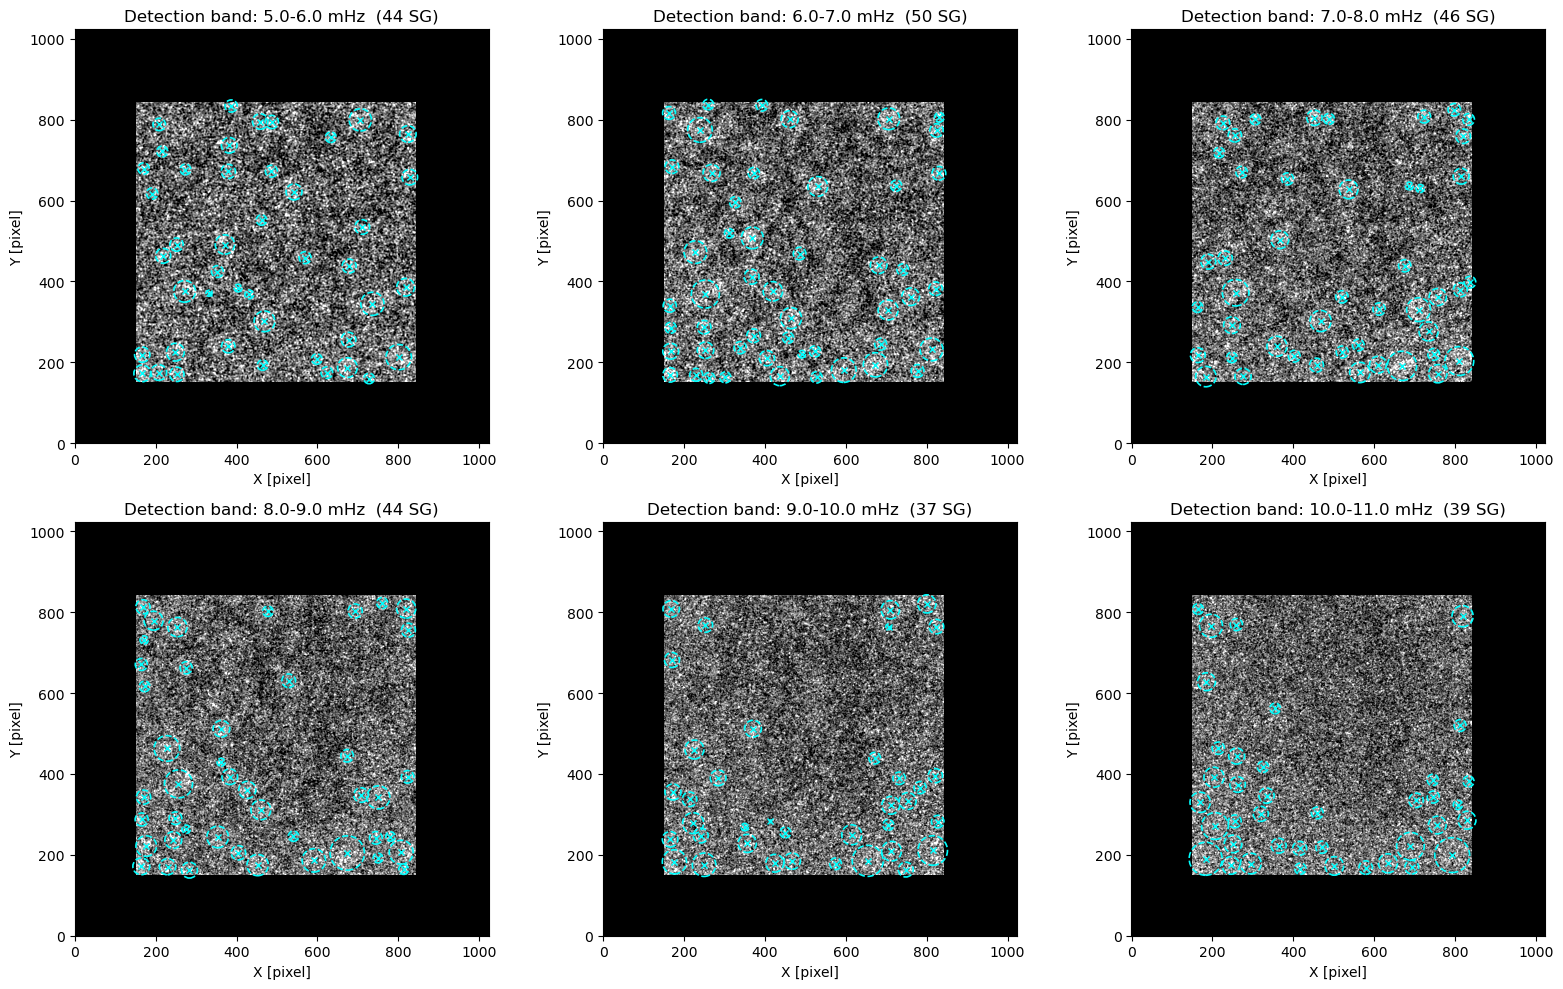

In [35]:
# Diagnostic: circular masks over their own detection map, one panel per band
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, det, data_map in zip(axes, detections, detection_maps):

    valid = data_map[data_map != 0]
    vmin, vmax = np.nanpercentile(valid, [5, 98])

    ax.imshow(data_map, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)

    for i, sg in enumerate(det["supergranules"], start=1):
        circle = plt.Circle(
            (sg["x"], sg["y"]), sg["radius"],
            fill=False, linestyle="--", linewidth=1.2, color="cyan",
        )
        ax.add_patch(circle)
        ax.plot(sg["x"], sg["y"], marker="x", markersize=4, color="cyan")

    ax.set_title(f"Detection band: {det['label']}  ({len(det['supergranules'])} SG)")
    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")

plt.tight_layout()
plt.show()


## 5. Apply Each Set of Masks to the 9 Measurement Maps

For each detection band's fixed set of circular masks, measure the mean egression power inside every mask, in every one of the 9 wide maps — same logic as the guide notebook's cell 12, repeated once per detection band.

In [40]:
def mean_power_across_maps(egression_maps, individual_masks):
    """
    For a FIXED set of circular masks, compute, for every map in
    egression_maps:
      - the mean value inside each individual mask,
      - the mean of those per-supergranule means (one number per map),
      - the std over ALL valid pixels inside all masks (one number per map).
    """
    mean_values_per_map = []
    mean_all_per_map = []
    std_all_per_map = []

    for data_map in egression_maps:

        mean_values = []
        all_values = []

        for mask in individual_masks.values():
            values = data_map[mask]
            mean_values.append(np.nanmean(values))
            all_values.append(values)

        mean_values = np.array(mean_values)
        mean_values_per_map.append(mean_values)

        mean_all_per_map.append(np.nanmean(mean_values))

        all_values = np.concatenate(all_values) if all_values else np.array([])
        std_all_per_map.append(np.nanstd(all_values))

    return (
        mean_values_per_map,
        np.array(mean_all_per_map),
        np.array(std_all_per_map),
    )


In [41]:
for det in detections:

    mean_values_per_map, mean_all_per_map, std_all_per_map = mean_power_across_maps(
        egression_maps, det["individual_masks"]
    )

    det["mean_values_per_map"] = mean_values_per_map
    det["mean_all_per_map"] = mean_all_per_map
    det["std_all_per_map"] = std_all_per_map

    print(f"Detection band {det['label']:>14s} -> mean power per measurement map:")
    print("   ", np.round(mean_all_per_map, 4))


Detection band    5.0-6.0 mHz -> mean power per measurement map:
    [100698.4841 311975.348   84381.7611  15040.787    5311.5922   2904.486
   1485.9096    892.4289    653.128 ]
Detection band    6.0-7.0 mHz -> mean power per measurement map:
    [100980.8697 312082.3355  84460.5449  14679.3256   5383.2858   2900.1547
   1490.5478    900.2889    655.7693]
Detection band    7.0-8.0 mHz -> mean power per measurement map:
    [101113.8073 311425.8567  84355.3199  14731.9021   5321.438    2966.0656
   1485.9826    897.6719    654.3074]
Detection band    8.0-9.0 mHz -> mean power per measurement map:
    [101738.4072 312276.5489  85135.356   14725.6424   5329.443    2908.3212
   1512.6118    904.4664    657.8063]
Detection band   9.0-10.0 mHz -> mean power per measurement map:
    [101794.7611 312253.2108  84464.0598  14464.0757   5260.5897   2881.0237
   1481.777     916.5989    658.7327]
Detection band  10.0-11.0 mHz -> mean power per measurement map:
    [103193.837  313410.3421  83620.

## 6. Diagnostic: Circular Masks Overlaid on the 9 Measurement Maps

Same style as the guide notebook's cell 10, but now parametrized so it can be run for **any** of the 6 detection bands. By default it shows the overlay for the first detection band (5.0-6.0 mHz); change `detection_index` to inspect another one.

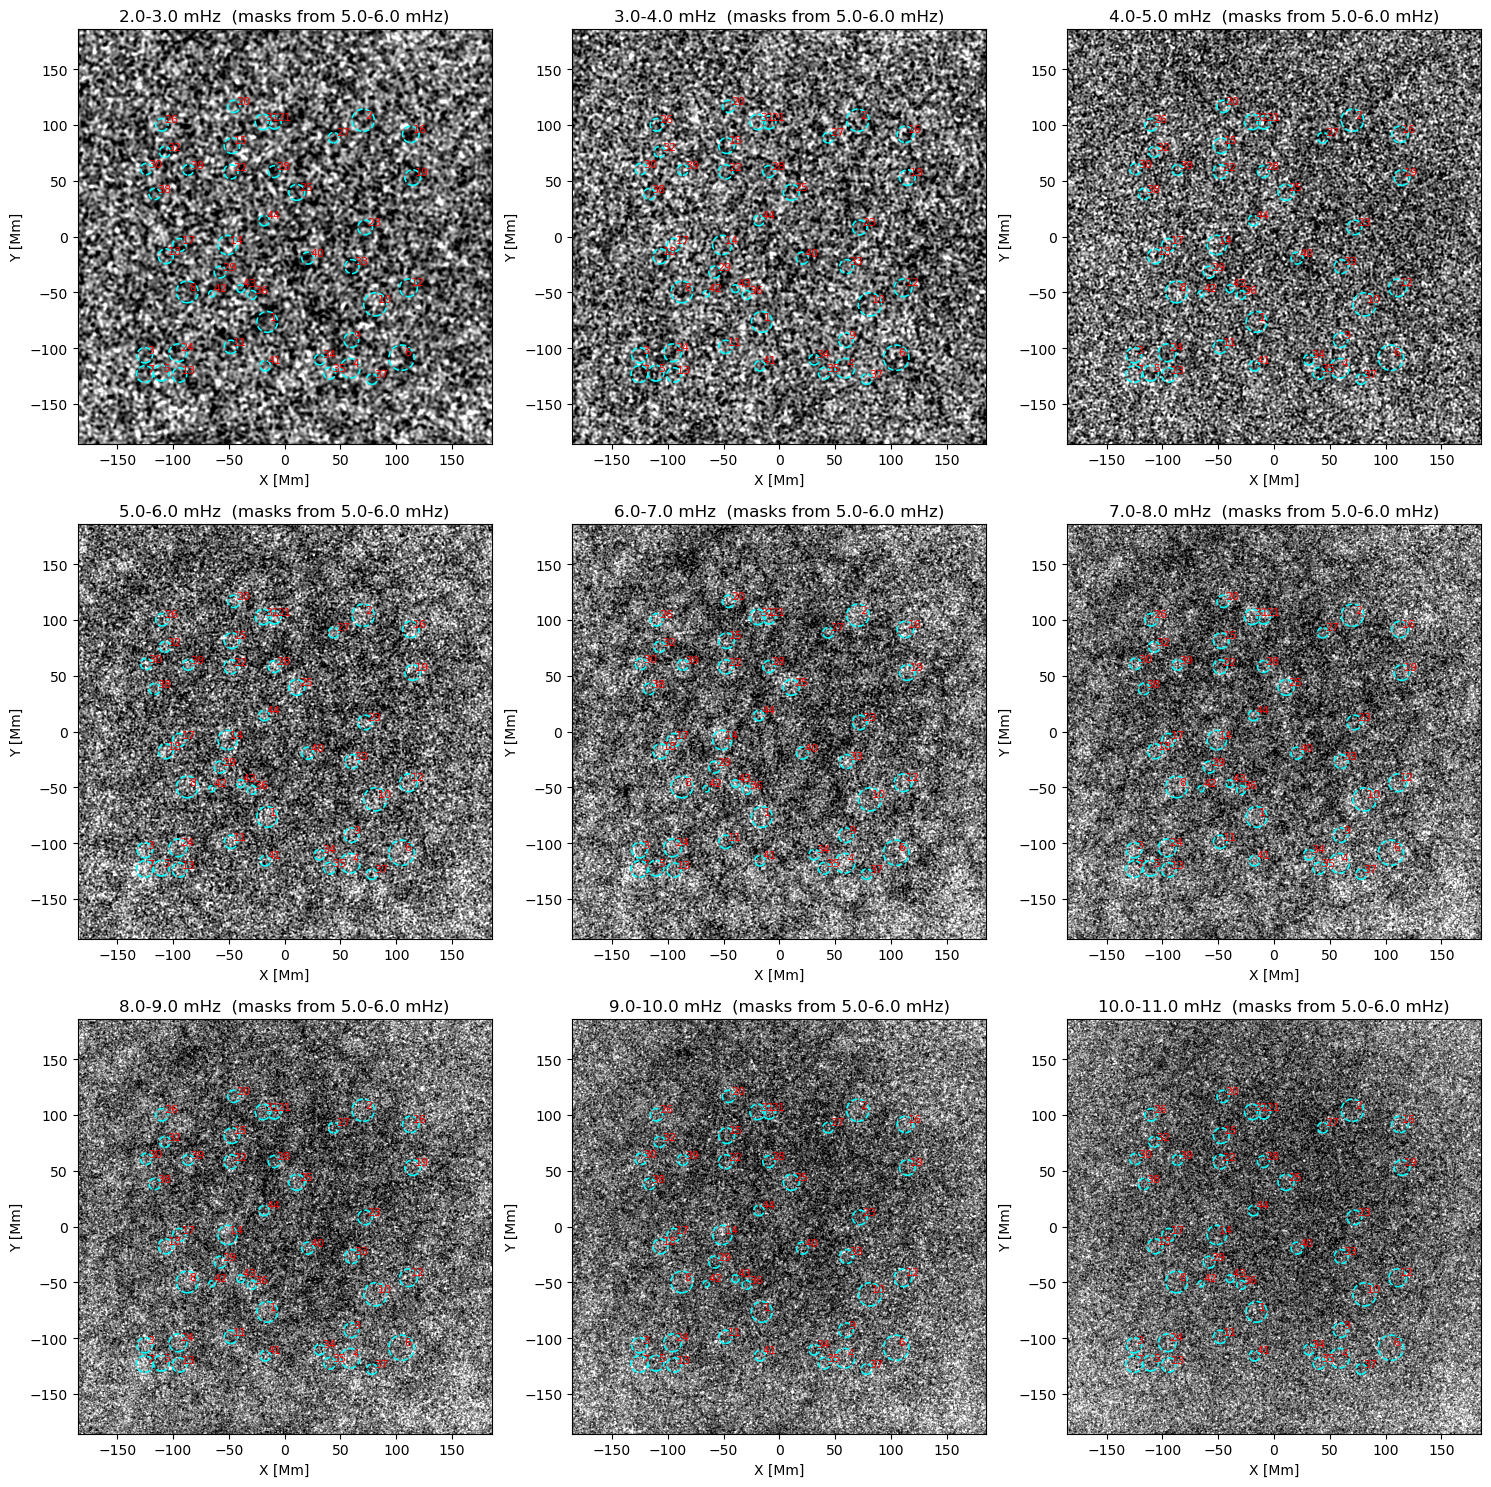

In [42]:
def plot_masks_over_measurement_maps(det, egression_maps, measurement_frequencies, extent):

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.ravel()

    for ax, data_map, freq_band in zip(axes, egression_maps, measurement_frequencies):

        valid = data_map[data_map != 0]
        vmin, vmax = np.nanpercentile(valid, [5, 98])

        ax.imshow(data_map, origin="lower", cmap="gray", vmin=vmin, vmax=vmax, extent=extent)

        ny, nx = data_map.shape
        for sg_id, sg in enumerate(det["supergranules"], start=1):
            x_mm = (sg["x"] - nx / 2) * spatial_sample
            y_mm = (sg["y"] - ny / 2) * spatial_sample
            r_mm = sg["radius"] * spatial_sample

            circle = plt.Circle(
                (x_mm, y_mm), r_mm,
                fill=False, linestyle="--", linewidth=1.2, color="cyan",
            )
            ax.add_patch(circle)
            ax.text(x_mm + 2, y_mm + 2, str(sg_id), fontsize=8, color="red")

        ax.set_title(f"{freq_band}  (masks from {det['label']})")
        ax.set_xlabel("X [Mm]")
        ax.set_ylabel("Y [Mm]")

    plt.tight_layout()
    plt.show()


detection_index = 0  # 0 -> 5.0-6.0 mHz ... 5 -> 10.0-11.0 mHz
plot_masks_over_measurement_maps(
    detections[detection_index], egression_maps, measurement_frequencies, extent
)


## 7. Final Plot: Mean Egression Power vs Frequency — 6 Curves

One curve per detection band. Each curve has 9 points (one per measurement map, from 2-3 mHz to 10-11 mHz), with error bars given by the std over all valid pixels inside that band's masks.

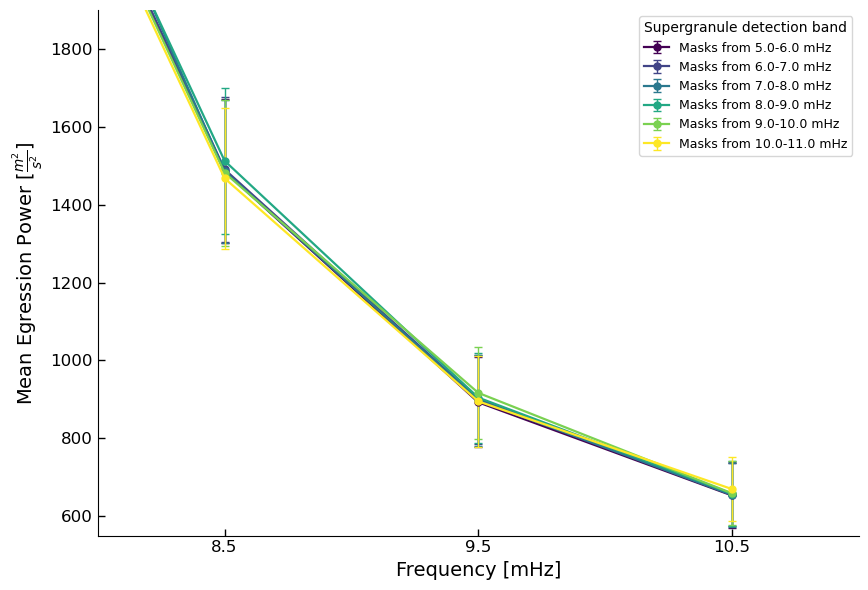

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(detections)))

for det, color in zip(detections, colors):
    ax.errorbar(
        central_frequencies,
        det["mean_all_per_map"],
        yerr=det["std_all_per_map"],
        fmt='o-',
        markersize=5,
        linewidth=1.6,
        elinewidth=1.0,
        capsize=3,
        capthick=1.0,
        color=color,
        label=f"Masks from {det['label']}",
    )

ax.set_xlabel('Frequency [mHz]', fontsize=14)
ax.set_ylabel(r'Mean Egression Power [$\frac{m^2}{s^2}$]', fontsize=14)

ax.tick_params(axis='both', which='major', labelsize=12, direction='in', length=5, width=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(central_frequencies)

ax.legend(title="Supergranule detection band", fontsize=9, title_fontsize=10, loc="best")

fig.tight_layout()
plt.ylim(550,1900)
plt.xlim(8,11)
plt.show()
